In [1]:
datasets = [
    "mnist_red30_incremental",
    "mnist_red30_sml",
    # "fashion_mnist_red50_incremental",
    # "fashion_mnist_red50_sml",
    # "fashion_mnist_red50_sml_2",
    # "fashion_mnist_red50_sml_3",
    # "mnist_red30_sml_2",
    # "mnist_red30_sml_3",
]
root = "/Users/federicogiannini/Library/CloudStorage/OneDrive-PolitecnicodiMilano/SML_CL"
nconfs = 10
save = True
suffixes = []

In [2]:
import pickle
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd

In [7]:
import scienceplots

In [3]:
models_to_remove = ["ewc", "mir", "lwf", "hat", 'er_lwf', 'pnn']

In [56]:
def rename_model(x):
    if x=="naive":
        return "Naive"
    return x.upper()

In [10]:
def color(m):
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color'] + []
    extra_colors = [
        '#e41a1c',  # rosso vivo
        '#377eb8',  # blu acceso
        '#4daf4a',  # verde brillante
        '#984ea3',  # viola intenso
        '#ff7f00',  # arancione scuro
        '#ffff33',  # giallo limone (usa con sfondi scuri)
    ]
    colors += extra_colors
    models = ["naive"] + sorted([x for x in list(cl_table.keys()) if x!="drifts" and x!="naive"])
    models += models_to_remove
    i = [i for i in range(len(models)) if models[i]==m]
    if len(i)>0:
        i = i[0]
    else:
        i = 0
    return colors[i]

In [66]:
cm = 1 / 2.54

def plot_kappa(perf, dataset):
    plt.style.use(['science', 'ieee'])
    plt.rcParams.update({'font.size': 8})
    
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6.5*cm, 5*cm))
    for m in perf:
        if m in models_to_remove:
            continue
        linestyle = "-"
        ax.plot(perf[m], label=rename_model(m), linestyle=linestyle, color=color(m))
        ax.scatter(x=np.arange(0,len(perf[m])), y=perf[m], s=15, color=color(m))
    ax.set_xticks(np.arange(0,len(perf[m])))
    ax.set_xticklabels([f"concept$_{i+1}$" for i in range(0,len(perf[m]))], rotation=90)
    #ax.legend(loc="best")
    if "sml" in dataset:
        #ax.set_title("Real drift scenario")
        scenario = "real"
    else:
        #ax.set_title("Virtual drift scenario")
        scenario = "virtual"
    ax.set_ylabel("Cohen's Kappa")
    ax.tick_params(axis='x', which='minor', bottom=False, top=False)
    plt.tight_layout()
    ax.legend()
    # plt.grid()
    display(fig)
    if save:
        plt.savefig(os.path.join(root, "performance", f"{dataset.split('_red')[0]}_cl_{scenario}_kappa.png"), dpi=300)
        plt.savefig(os.path.join(root, "performance", f"{dataset.split('_red')[0]}_cl_{scenario}_kappa.eps"), format="eps")
    plt.close(fig)

,model,average,a_metric
0,AGEM,0.24 ± 0.01,0.24 ± 0.01
1,ARF,0.24 ± 0.00,0.24 ± 0.00
2,ER,0.27 ± 0.02,0.27 ± 0.02
3,Naive,0.24 ± 0.01,0.24 ± 0.01


mnist_red30_incremental


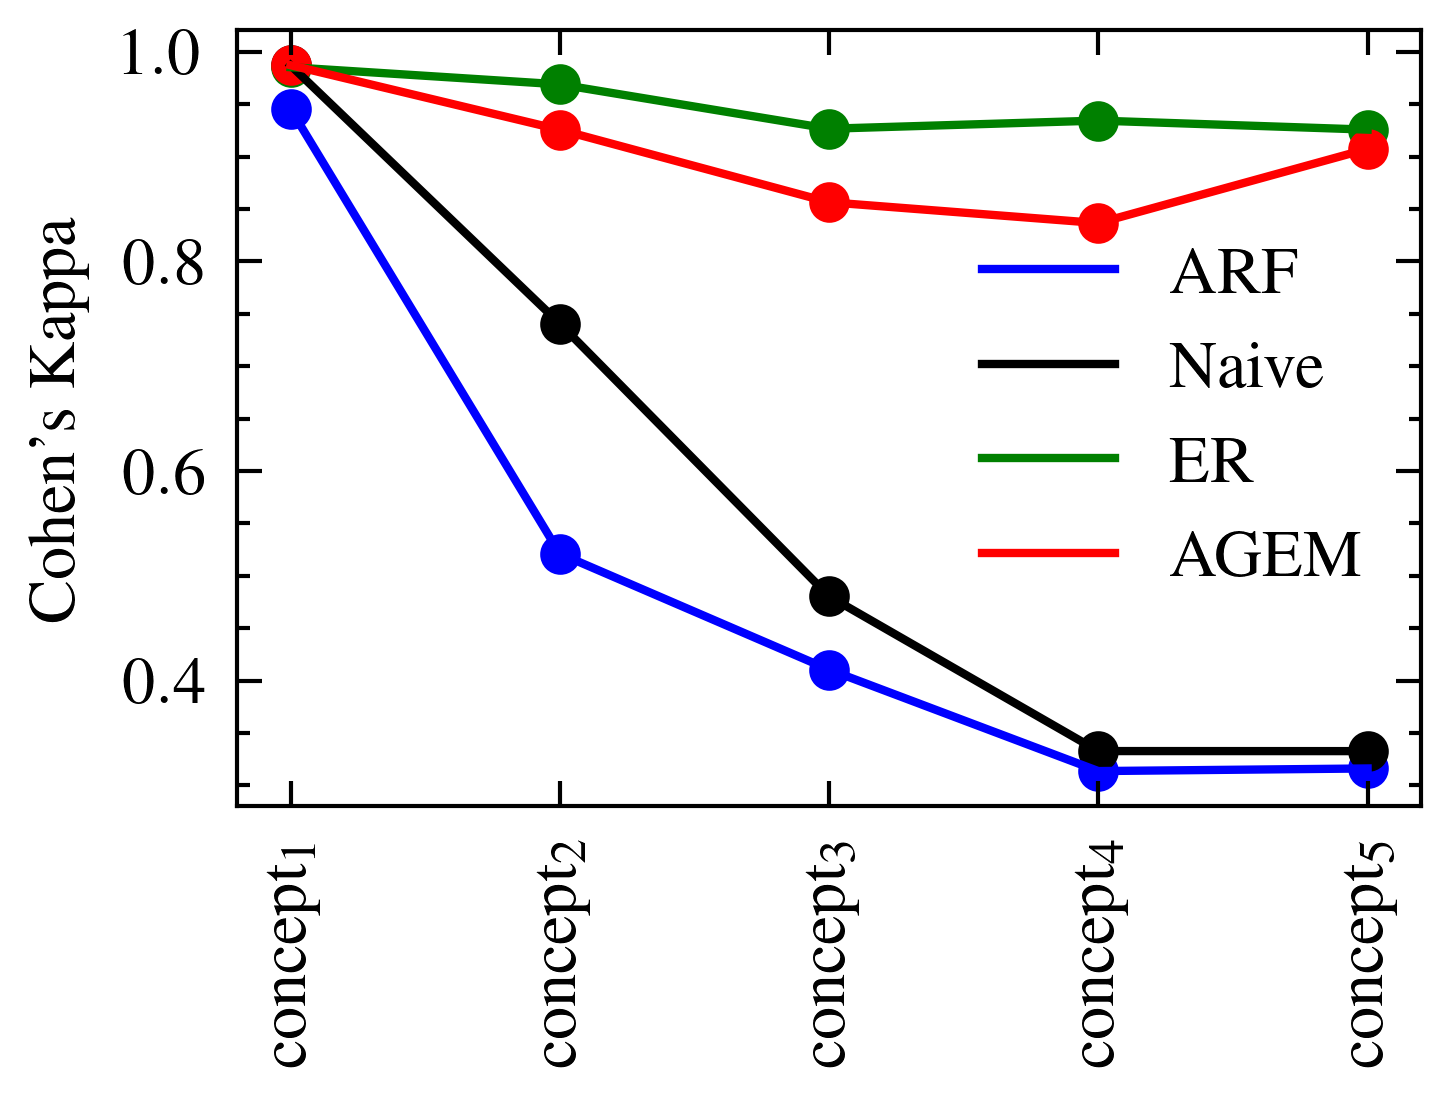

,model,average,bwt
0,AGEM,0.89 ± 0.06,-0.13 ± 0.10
1,ARF,0.40 ± 0.09,-0.83 ± 0.14
2,ER,0.94 ± 0.02,-0.04 ± 0.02
3,Naive,0.46 ± 0.09,-0.77 ± 0.14


mnist_red30_sml


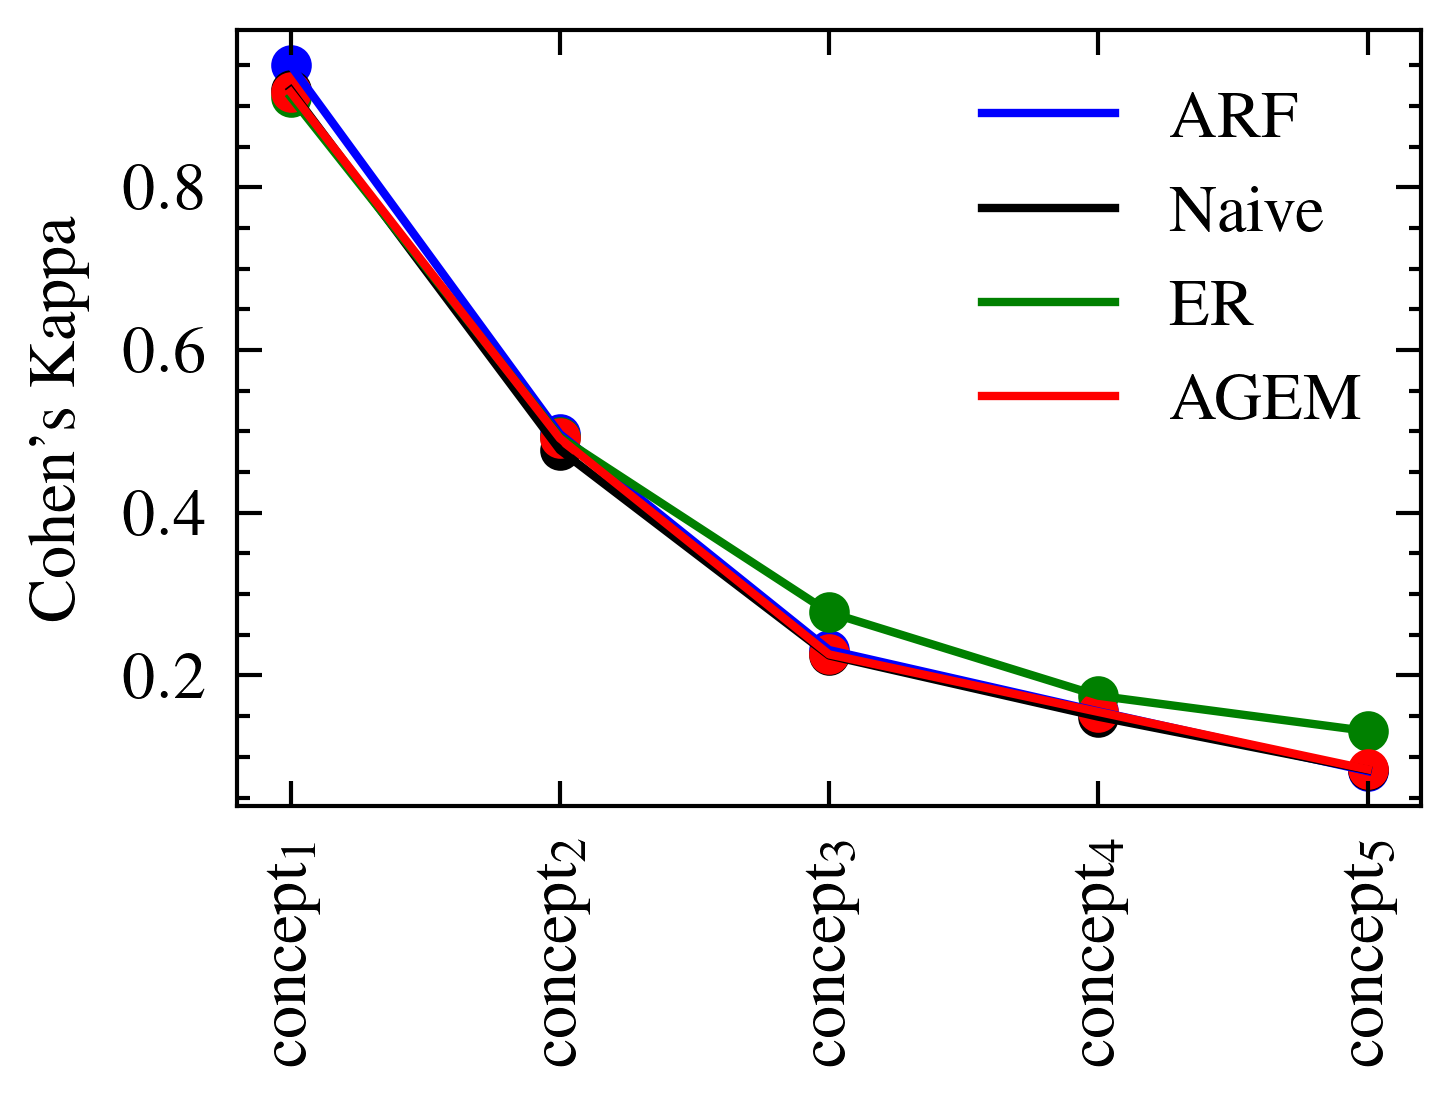

,model,average,bwt
0,AGEM,0.24 ± 0.01,-0.99 ± 0.05
1,ARF,0.24 ± 0.00,-1.06 ± 0.00
2,ER,0.27 ± 0.02,-0.85 ± 0.08
3,Naive,0.24 ± 0.01,-1.00 ± 0.04


In [67]:
if type(nconfs)==int:
    nconfs = [nconfs]*len(datasets)
for dataset, nconf in zip(datasets, nconfs):
    print(dataset)
    cl_tables = []
    for conf in range(1, nconf+1):
        with open(os.path.join(root, "performance", f"{dataset}_{conf}conf", "cl_table_sml.pkl"), "rb") as f:
            table = pickle.load(f)
        with open(os.path.join(root, "performance", f"{dataset}_{conf}conf", "cl_table_cl.pkl"), "rb") as f:
            table.update(pickle.load(f))
        for s in suffixes:
            with open(os.path.join(root, "performance", f"{dataset}_{conf}conf", f"cl_table_cl_{s}.pkl"), "rb") as f:
                table.update(pickle.load(f))
        models = list(table.keys())
        for m in models:
            if m in models_to_remove or "freezed" in m:
                del table[m]
        cl_tables.append(table)
    
    cl_table = {}
    for m in cl_tables[0]:
        cl_table[m] = {}
        for metric in ["accuracy", "kappa"]:
            cl_table[m][metric] = np.mean(np.array([table[m][metric] for table in cl_tables]), axis=0)
    
    cumulative = []
    for conf in range(nconf):
        cumulative.append({})
        for m in cl_tables[conf]:
            cumulative[-1][m] = []
            for i in range(len(cl_tables[conf][m]["kappa"])):
                cumulative[-1][m].append(np.mean(cl_tables[conf][m]["kappa"][i][:i+1]))
                
    cumulative_final = {}
    for m in cumulative[0]:
        cumulative_final[m] = np.mean(np.array([c[m] for c in cumulative]), axis=0)
    
    plot_kappa(cumulative_final, dataset)
    
    cl_metrics = []
    for conf, table in enumerate(cl_tables):
        cl_metrics.append({})
        for m in table:
            n = len(table[m]["kappa"])
            cl_metrics[-1][m] = {
                "average": np.mean(table[m]["kappa"][-1]),
                "a_metric": np.sum(
                    [
                        table[m]["kappa"][i][j]
                        for i in range(n)
                        for j in range(i+1)
                    ]
                )
                / (n * (n + 1) / 2),
                "bwt": np.sum(
                    [
                        (
                            table[m]["kappa"][i][j]
                            - table[m]["kappa"][j][j]
                        )
                        for i in range(1, n)
                        for j in range(i)
                    ]
                ) / (n * (n - 1) / 2),
                "conf": conf+1
            }  
    
    for i in range(len(cl_metrics)):
        cl_metrics[i] = pd.DataFrame(cl_metrics[i]).T.reset_index().rename(columns={'index': 'model'})
        
    cl_metrics = pd.concat(cl_metrics)
    if save:
        cl_metrics.to_excel(os.path.join(root, "performance", f"{dataset}_cl_metrics_all.xlsx"), index=False)
    cl_avg = cl_metrics.drop(columns=["conf", "average"])
    cl_avg["average"] = cl_avg["a_metric"]
    cl_avg = cl_avg[["model", "average", "bwt"]].groupby('model').agg(['mean', 'std'])
    cl_avg.columns = ['_'.join(col) for col in cl_avg.columns]
    cl_avg = cl_avg.reset_index()
    cl_avg["model"] = cl_avg["model"].apply(rename_model)
    cl_avg = cl_avg.sort_values("model")
    for c in cl_avg:
        if c!="model":
            cl_avg[c] = cl_avg[c].map(lambda x: f"{x:.2f}")
    for c in ["average", "bwt"]:
        cl_avg[c] = cl_avg[f"{c}_mean"] + " ± " + cl_avg[f"{c}_std"]
        cl_avg = cl_avg.drop(columns=[f"{c}_mean", f"{c}_std"])
    if save:
        cl_avg.to_excel(os.path.join(root, "performance", f"{dataset}_cl_metrics.xlsx"), index=False)
    
    display(cl_avg)